In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\rimpa\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [8]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


TASK 1: Compute Daily Returns

In [10]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [11]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
nav.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

TASK 2: Compute CAGR

In [13]:
cagr_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
        -
        1
    )

    cagr_data.append(
        [fund, cagr]
    )

cagr_report = pd.DataFrame(
    cagr_data,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

In [14]:
cagr_report.to_csv(
    "../reports/cagr_report.csv",
    index=False
)

TASK 3: Compute Sharpe Ratio

In [15]:
risk_free = 0.065

sharpe_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    annual_return = (
        returns.mean()
        *
        252
    )

    annual_volatility = (
        returns.std()
        *
        np.sqrt(252)
    )

    sharpe = (
        annual_return
        -
        risk_free
    ) / annual_volatility

    sharpe_data.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

In [16]:
sharpe_df.to_csv(
    "../reports/sharpe_values.csv",
    index=False
)

TASK 4: Compute Sortino Ratio

In [17]:
sortino_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']
        ==
        fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean()
        *
        252
    )

    downside_std = (
        downside.std()
        *
        np.sqrt(252)
    )

    sortino = (
        annual_return
        -
        risk_free
    ) / downside_std

    sortino_data.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [18]:
sortino_df.to_csv(
    "../reports/sortino_values.csv",
    index=False
)

TASK 5: Compute Alpha & Beta vs Benchmark

In [19]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [20]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [21]:
from scipy.stats import linregress

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')
    ['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [22]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50[
    ['date', 'benchmark_return']
]

In [23]:
alpha_beta_data = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty50,
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_data.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_data,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [24]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

TASK 6: Maximum Drawdown

In [25]:
max_dd_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp['rolling_max'] = (
        temp['nav']
        .cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        -
        temp['rolling_max']
    ) / temp['rolling_max']

    max_dd = (
        temp['drawdown']
        .min()
    )

    max_dd_data.append(
        [fund, max_dd]
    )

max_dd_df = pd.DataFrame(
    max_dd_data,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [26]:
max_dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

TASK 7: Fund Scorecard

In [27]:
scorecard = (
    cagr_report
    .merge(sharpe_df, on='amfi_code')
    .merge(max_dd_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,max_drawdown,alpha,beta
0,100016,0.026352,-0.201517,-0.247344,0.036221,-0.025909
1,100025,0.044551,-0.567095,-0.043083,0.043189,-0.016176
2,100033,0.300997,1.093699,-0.162172,0.272343,-0.011200
3,101206,0.235205,1.027213,-0.112916,0.213945,0.033814
4,101207,0.079331,0.162661,-0.354469,0.108205,-0.059856


In [28]:
scorecard['cagr_rank'] = scorecard['cagr'].rank(
    ascending=False
)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(
    ascending=False
)

scorecard['alpha_rank'] = scorecard['alpha'].rank(
    ascending=False
)

# Lower drawdown is better
scorecard['maxdd_rank'] = scorecard['max_drawdown'].rank(
    ascending=True
)

In [29]:
scorecard['fund_score'] = (
    0.35 * scorecard['cagr_rank']
    +
    0.30 * scorecard['sharpe_rank']
    +
    0.25 * scorecard['alpha_rank']
    +
    0.10 * scorecard['maxdd_rank']
)

In [30]:
scorecard = scorecard.sort_values(
    by='fund_score'
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,max_drawdown,alpha,beta,cagr_rank,sharpe_rank,alpha_rank,maxdd_rank,fund_score
25,120505,0.328016,1.180101,-0.181885,0.293014,-0.017391,1.0,5.0,3.0,16.0,4.20
36,148569,0.319245,1.234930,-0.163967,0.283473,-0.010201,4.0,3.0,4.0,20.0,5.30
21,119598,0.323981,0.945308,-0.287060,0.301114,0.074266,2.0,14.0,1.0,5.0,5.65
39,149324,0.322621,0.949796,-0.311719,0.298179,0.132608,3.0,13.0,2.0,4.0,5.85
30,120843,0.308833,1.306744,-0.129740,0.272784,-0.008737,6.0,2.0,5.0,28.0,6.75
34,148567,0.309499,1.448291,-0.112657,0.271150,-0.028133,5.0,1.0,7.0,33.0,7.10
2,100033,0.300997,1.093699,-0.162172,0.272343,-0.011200,7.0,7.0,6.0,21.0,8.15
38,149323,0.295581,1.132122,-0.172481,0.265836,0.003479,8.0,6.0,8.0,19.0,8.50
19,119551,0.257849,1.208267,-0.150124,0.232196,-0.056045,10.0,4.0,10.0,24.0,9.60
16,119094,0.281926,0.998231,-0.209609,0.259971,-0.059868,9.0,11.0,9.0,13.0,10.00


In [31]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [32]:
scorecard[
    [
        'amfi_code',
        'cagr',
        'sharpe_ratio',
        'alpha',
        'beta',
        'max_drawdown',
        'fund_score'
    ]
].head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,fund_score
25,120505,0.328016,1.180101,0.293014,-0.017391,-0.181885,4.20
36,148569,0.319245,1.234930,0.283473,-0.010201,-0.163967,5.30
21,119598,0.323981,0.945308,0.301114,0.074266,-0.287060,5.65
39,149324,0.322621,0.949796,0.298179,0.132608,-0.311719,5.85
30,120843,0.308833,1.306744,0.272784,-0.008737,-0.129740,6.75
34,148567,0.309499,1.448291,0.271150,-0.028133,-0.112657,7.10
2,100033,0.300997,1.093699,0.272343,-0.011200,-0.162172,8.15
38,149323,0.295581,1.132122,0.265836,0.003479,-0.172481,8.50
19,119551,0.257849,1.208267,0.232196,-0.056045,-0.150124,9.60
16,119094,0.281926,0.998231,0.259971,-0.059868,-0.209609,10.00


TASK 8: Benchmark Comparison Chart

In [33]:
top5_funds = (
    scorecard
    .sort_values('fund_score')
    .head(5)
)

top5_codes = top5_funds['amfi_code'].tolist()

top5_codes

[120505, 148569, 119598, 149324, 120843]

In [34]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50.sort_values('date')

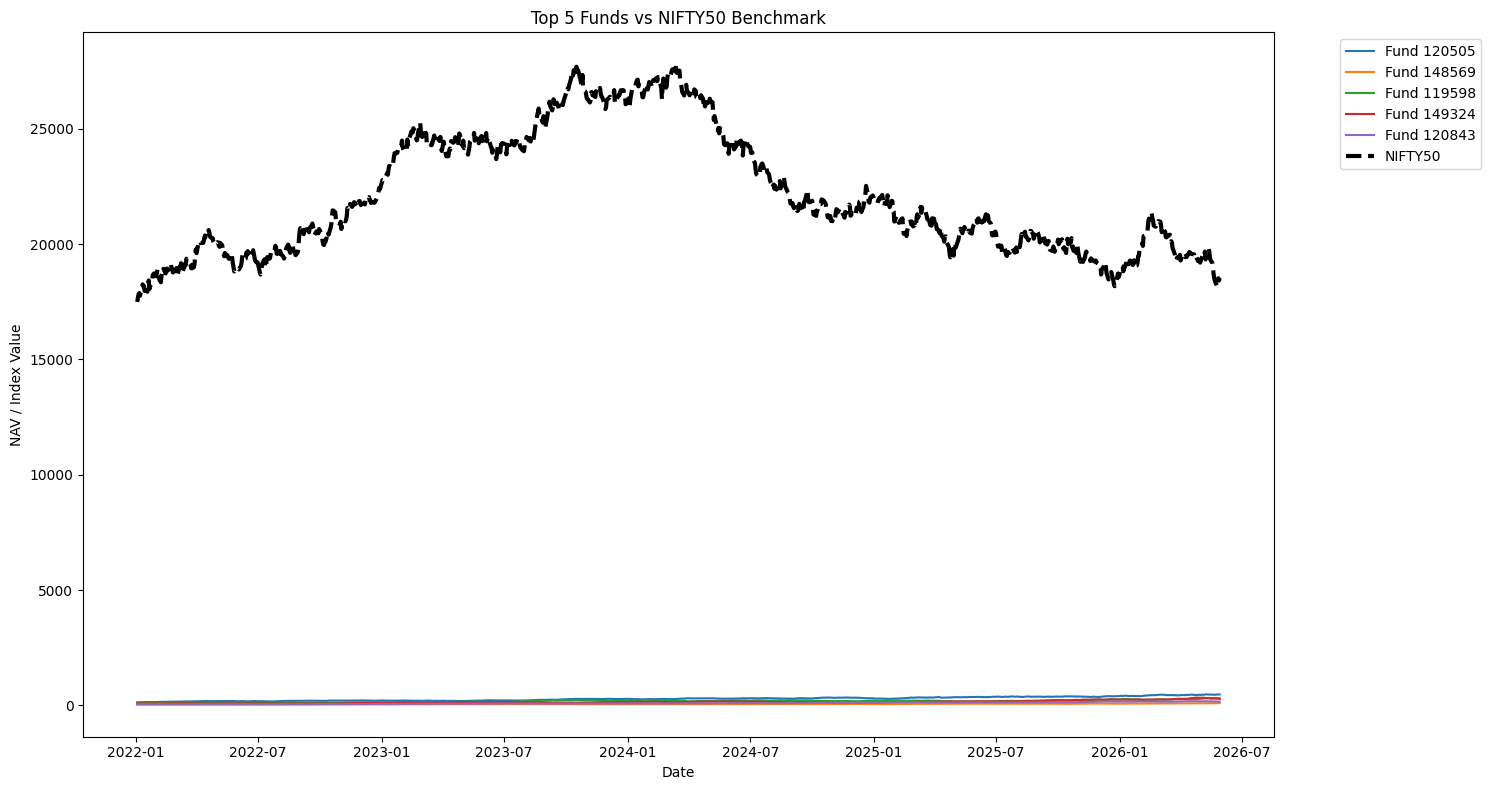

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

# Plot Top 5 Funds
for fund in top5_codes:

    temp = nav[
        nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=f'Fund {fund}'
    )

# Plot Benchmark
plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    color='black',
    linewidth=3,
    linestyle='--',
    label='NIFTY50'
)

plt.title(
    'Top 5 Funds vs NIFTY50 Benchmark'
)

plt.xlabel('Date')
plt.ylabel('NAV / Index Value')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.tight_layout()

# Save PNG
plt.savefig(
    "../reports/benchmark_chart.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()